## 📝 Instrucciones para construir el modelo de regresion lineal ##


**Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)**

Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos y queremos descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.

Para ello, es necesario que establezcas una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.

## Paso 1: Carga del conjunto de datos a tu modelo

In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler


El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre demographic_health_data.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv

In [2]:
df = pd.read_csv('../data/raw/demographic_health_data.csv', delimiter= ',')

## Paso 2: Realiza un EDA completo

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

In [3]:
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [5]:
df.shape

(3140, 108)

**Con tantas columnas es clave la decisión de qué variable será el objetivo para el análisis**

In [6]:
#mirar todas las columnas
cols = df.columns.to_list()
for i, col in enumerate(cols):
    print(f"{i}: {col}")

0: fips
1: TOT_POP
2: 0-9
3: 0-9 y/o % of total pop
4: 19-Oct
5: 10-19 y/o % of total pop
6: 20-29
7: 20-29 y/o % of total pop
8: 30-39
9: 30-39 y/o % of total pop
10: 40-49
11: 40-49 y/o % of total pop
12: 50-59
13: 50-59 y/o % of total pop
14: 60-69
15: 60-69 y/o % of total pop
16: 70-79
17: 70-79 y/o % of total pop
18: 80+
19: 80+ y/o % of total pop
20: White-alone pop
21: % White-alone
22: Black-alone pop
23: % Black-alone
24: Native American/American Indian-alone pop
25: % NA/AI-alone
26: Asian-alone pop
27: % Asian-alone
28: Hawaiian/Pacific Islander-alone pop
29: % Hawaiian/PI-alone
30: Two or more races pop
31: % Two or more races
32: POP_ESTIMATE_2018
33: N_POP_CHG_2018
34: GQ_ESTIMATES_2018
35: R_birth_2018
36: R_death_2018
37: R_NATURAL_INC_2018
38: R_INTERNATIONAL_MIG_2018
39: R_DOMESTIC_MIG_2018
40: R_NET_MIG_2018
41: Less than a high school diploma 2014-18
42: High school diploma only 2014-18
43: Some college or associate's degree 2014-18
44: Bachelor's degree or higher 2

**preseleccionamos las 3 variables contínuas que están relacionadas con la salud: prevalencia de obesidad, diabetes y heart disease**

In [7]:
#hacemos un describe que incluya las variables preselccionadas
df.describe()[['diabetes_prevalence','Heart disease_prevalence', 'Obesity_prevalence']]

,diabetes_prevalence,Heart disease_prevalence,Obesity_prevalence
count,3140.000000,3140.000000,3140.000000
mean,13.073503,8.607803,35.019299
std,2.724351,1.758587,4.517088
min,6.100000,3.500000,15.200000
25%,11.200000,7.400000,32.400000
50%,12.800000,8.600000,35.400000
75%,14.800000,9.800000,37.900000
max,25.600000,15.100000,49.900000


Text(0.5, 1.0, 'Obesity Prevalence')

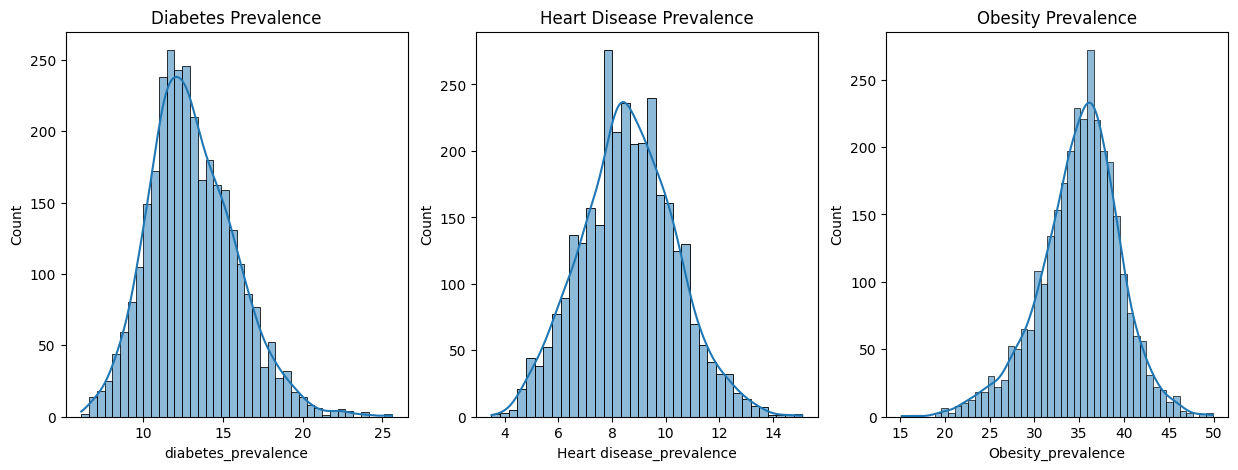

In [8]:
#miramos la normaliddad de estas 3 variables:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['diabetes_prevalence'], ax=axes[0], kde=True)
axes[0].set_title('Diabetes Prevalence')
sns.histplot(df['Heart disease_prevalence'], ax=axes[1], kde=True)
axes[1].set_title('Heart Disease Prevalence')
sns.histplot(df['Obesity_prevalence'], ax=axes[2], kde=True)
axes[2].set_title('Obesity Prevalence')

**Seleccionamos heart disease_prevalence por la normalidad de su distribución y por interés personal**

*Comenzamos con la limpieza...*

In [9]:
#quitamos ids
df = df.drop(columns=['fips'])

In [10]:
#miramos si hay variables con muchos valores nulos
df.isnull().sum().sort_values(ascending=False)

#no hay...

TOT_POP                     0
0-9                         0
0-9 y/o % of total pop      0
19-Oct                      0
10-19 y/o % of total pop    0
                           ..
CKD_prevalence              0
CKD_Lower 95% CI            0
CKD_Upper 95% CI            0
CKD_number                  0
Urban_rural_code            0
Length: 107, dtype: int64

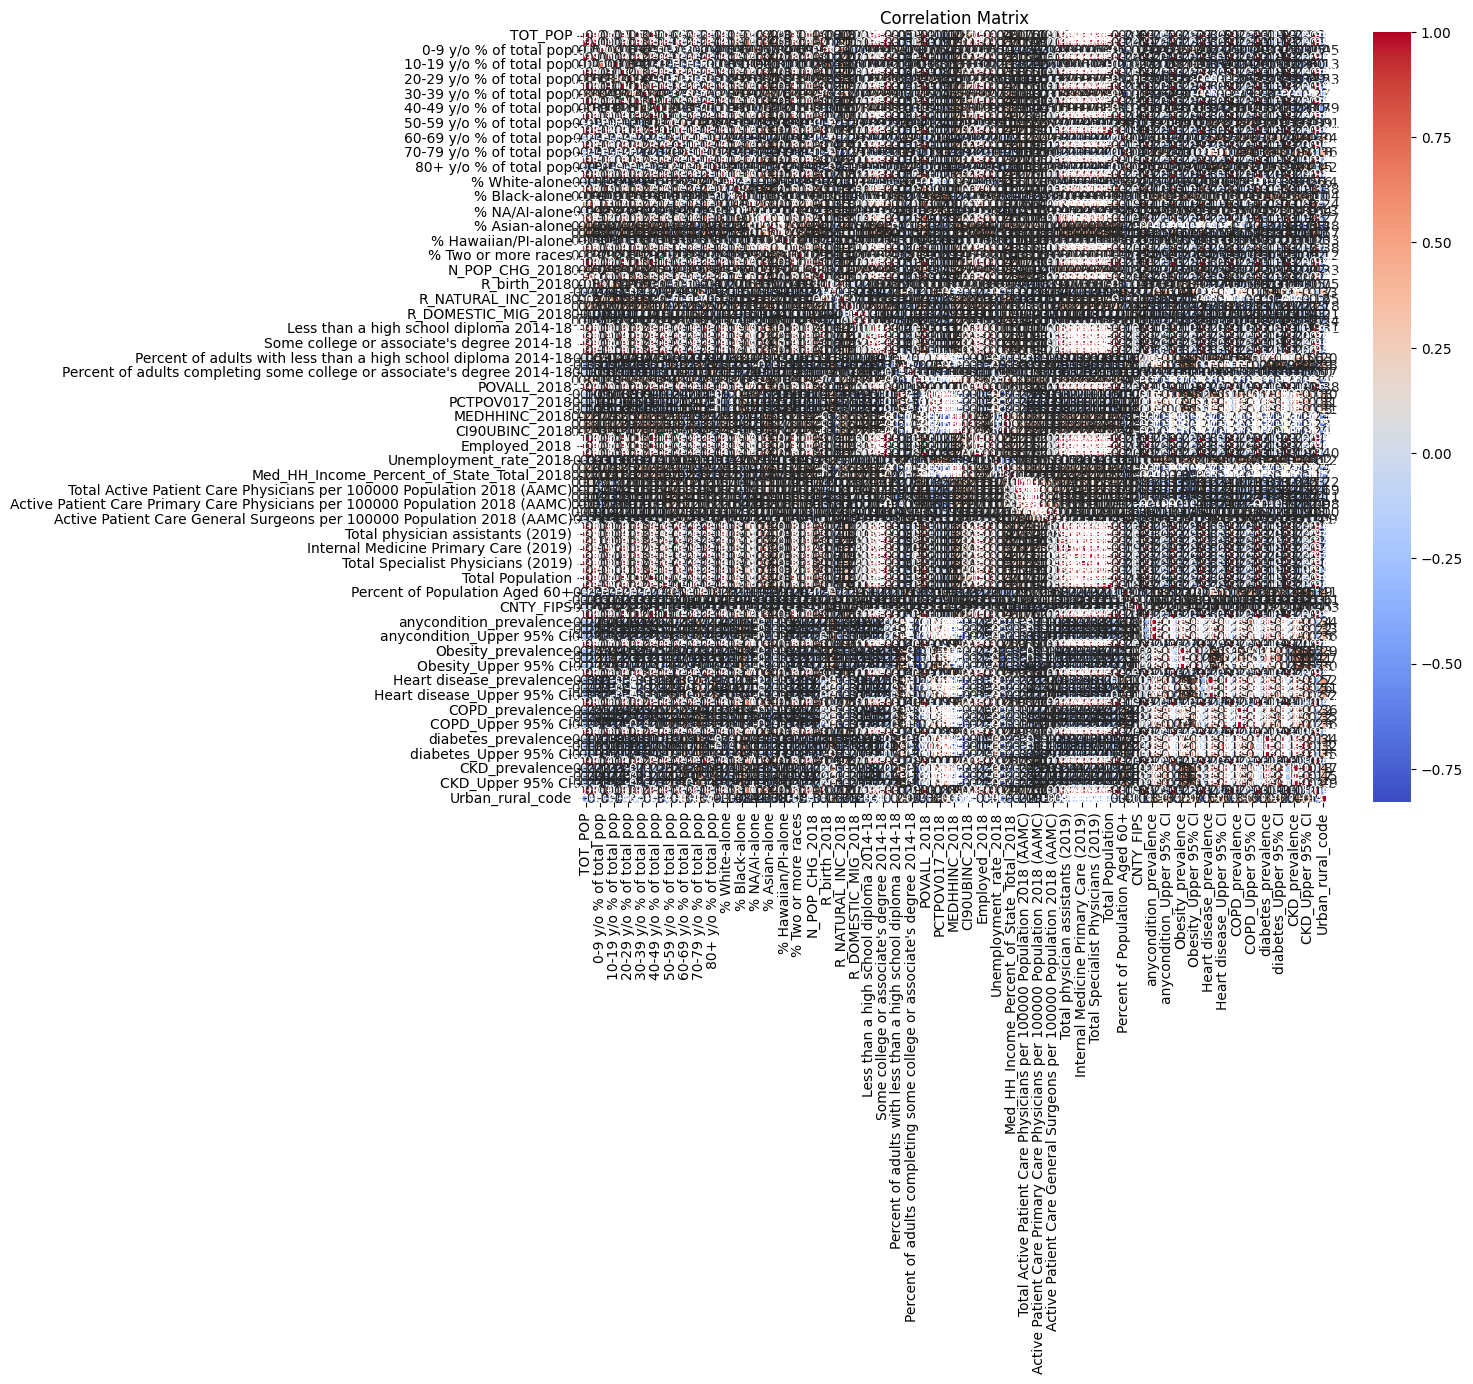

In [11]:
#revisamos multicolinealidad entre las variables
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Demasiadas variables para que visualmente sea efectivo. Lo intentaremos de nuevo cuando hayamos reducido el número de variables.

In [12]:
#Buscamos las variables con mayor correlación entre sí
# con np.triu lo que se busca es quedarnos solo con la parte superior de la matriz de correlación, para evitar redundancia y la k =1 es para no incluir la diagonal principal (que siempre es 1)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#buscamos las columnas que tienen una correlación mayor a 0.8 aprovechando que tenemos muchas variables
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

#cuantas variables estuvieron altamente correlacionadas?
print(len(to_drop))

69


In [13]:
#elminimamos variables seleccionadas
df_reduced = df.drop(columns=to_drop)
df_reduced.shape

(3140, 38)

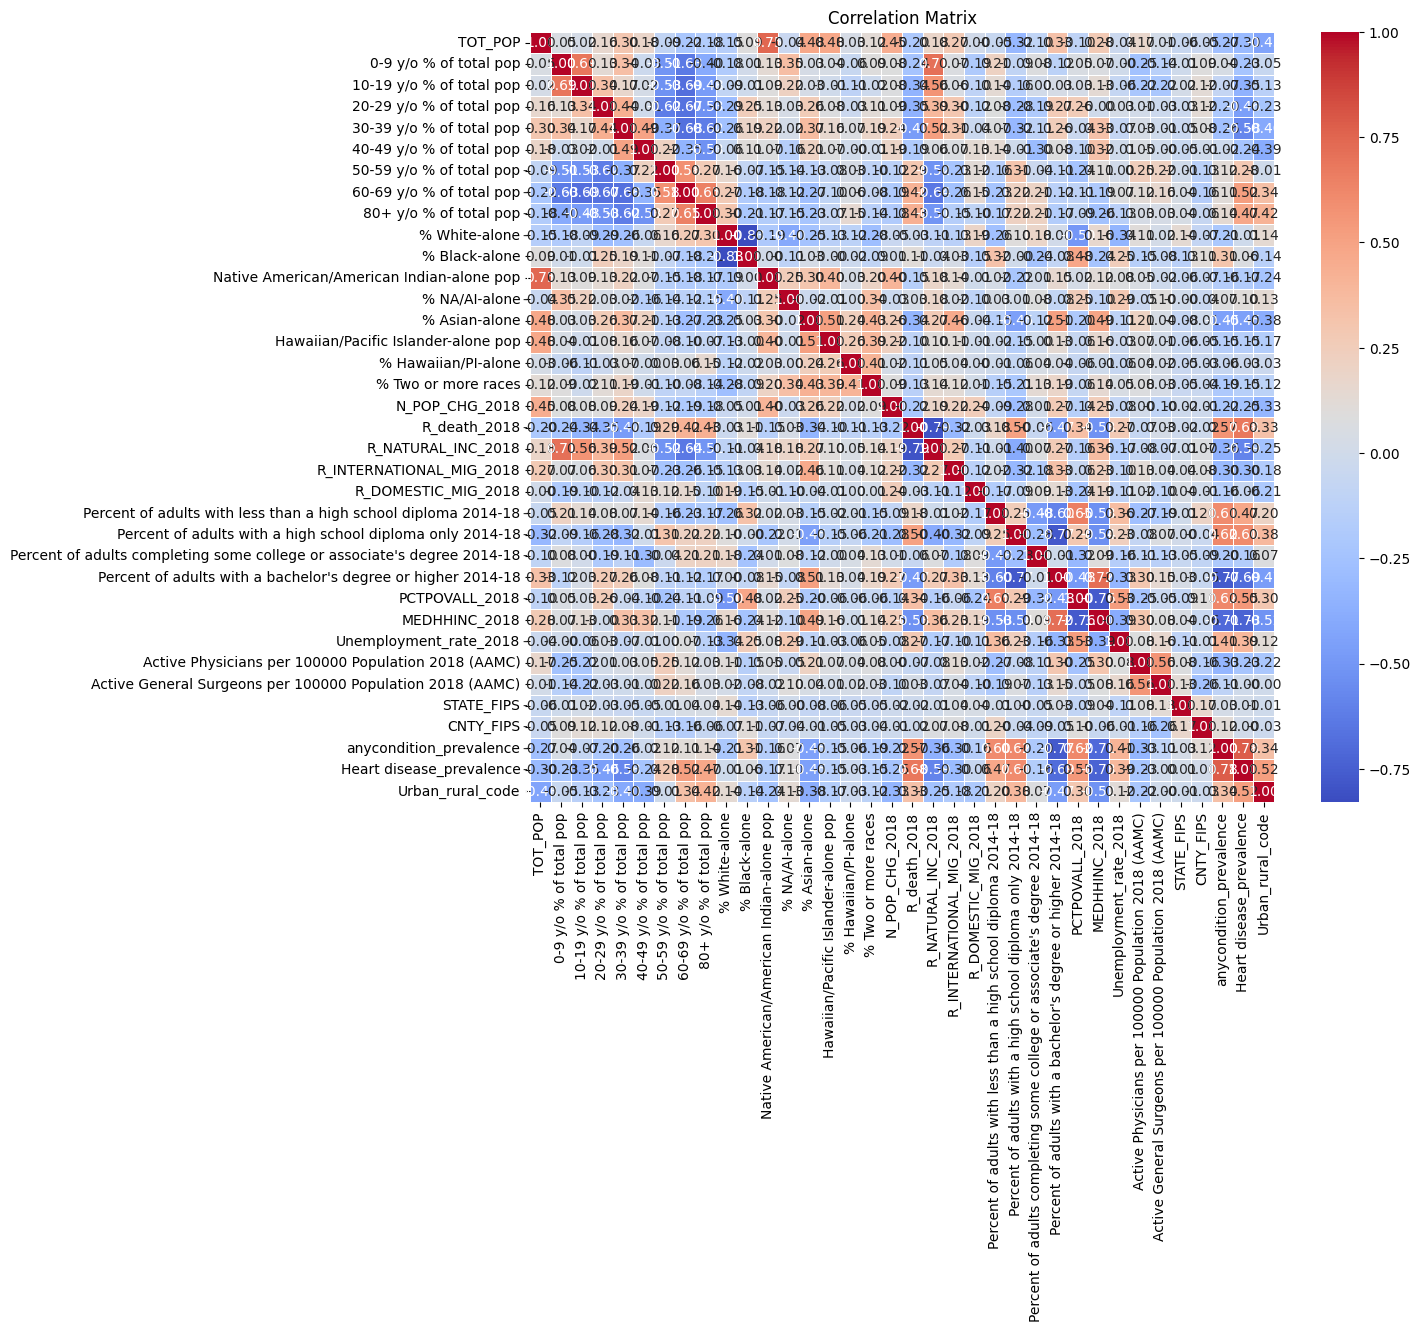

In [14]:
#probemos de nuevo con la matriz de correlación para ver si se redujo la multicolinealidad
corr_matrix = df_reduced.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [15]:
# Estadística descriptiva con las variables reducidas
df_reduced.describe()

,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,80+ y/o % of total pop,% White-alone,...,PCTPOVALL_2018,MEDHHINC_2018,Unemployment_rate_2018,Active Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),STATE_FIPS,CNTY_FIPS,anycondition_prevalence,Heart disease_prevalence,Urban_rural_code
count,3.140000e+03,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,1.041894e+05,11.871051,12.694609,12.283979,11.751535,11.556685,13.526733,13.182225,4.733801,84.494109,...,15.159459,52767.083758,4.131338,254.923567,7.621943,30.298089,103.551592,46.793917,8.607803,4.635350
std,3.335834e+05,2.124081,1.815044,3.126297,1.696599,1.372935,1.481692,2.532498,1.535028,16.348987,...,6.131874,13907.992668,1.503013,42.291759,1.288832,15.132325,107.689584,6.379448,1.758587,1.510447
min,8.800000e+01,0.000000,0.000000,0.000000,6.092789,2.631579,5.316361,3.444403,0.000000,3.841985,...,0.000000,0.000000,0.000000,191.300000,5.600000,1.000000,1.000000,22.000000,3.500000,1.000000
25%,1.096325e+04,10.594639,11.674504,10.496774,10.689322,10.685197,12.738561,11.621232,3.738648,79.620473,...,10.800000,43677.000000,3.100000,227.600000,6.900000,18.000000,35.000000,42.900000,7.400000,3.000000
50%,2.580050e+04,11.802727,12.687422,11.772649,11.580861,11.618372,13.621339,13.013409,4.565338,91.410189,...,14.100000,50564.500000,3.900000,247.100000,7.100000,29.000000,79.000000,47.200000,8.600000,5.000000
75%,6.791300e+04,12.951840,13.659282,13.182260,12.639379,12.386083,14.429115,14.467254,5.484143,95.521727,...,18.300000,58822.250000,4.800000,278.800000,8.300000,45.000000,133.000000,51.000000,9.800000,6.000000
max,1.010552e+07,25.460677,23.304372,37.570198,22.225129,19.430369,20.454545,27.272727,22.727273,99.043785,...,54.000000,140382.000000,19.900000,847.000000,25.300000,56.000000,840.000000,66.200000,15.100000,6.000000


In [16]:
#mirar todas las columnas
cols = df_reduced.columns.to_list()
for i, col in enumerate(cols):
    print(f"{i}: {col}")

0: TOT_POP
1: 0-9 y/o % of total pop
2: 10-19 y/o % of total pop
3: 20-29 y/o % of total pop
4: 30-39 y/o % of total pop
5: 40-49 y/o % of total pop
6: 50-59 y/o % of total pop
7: 60-69 y/o % of total pop
8: 80+ y/o % of total pop
9: % White-alone
10: % Black-alone
11: Native American/American Indian-alone pop
12: % NA/AI-alone
13: % Asian-alone
14: Hawaiian/Pacific Islander-alone pop
15: % Hawaiian/PI-alone
16: % Two or more races
17: N_POP_CHG_2018
18: R_death_2018
19: R_NATURAL_INC_2018
20: R_INTERNATIONAL_MIG_2018
21: R_DOMESTIC_MIG_2018
22: Percent of adults with less than a high school diploma 2014-18
23: Percent of adults with a high school diploma only 2014-18
24: Percent of adults completing some college or associate's degree 2014-18
25: Percent of adults with a bachelor's degree or higher 2014-18
26: PCTPOVALL_2018
27: MEDHHINC_2018
28: Unemployment_rate_2018
29: Active Physicians per 100000 Population 2018 (AAMC)
30: Active General Surgeons per 100000 Population 2018 (AAMC)


In [17]:
#quitemos algunas variables geográficas que no aportan nada a nuestro análisis - Dejamos Urban_rural_code porque es una variable que puede ser relevante para la salud
df_reduced = df_reduced.drop(columns=['STATE_FIPS', 'CNTY_FIPS', 'STATE_NAME','COUNTY_NAME'])

In [18]:
#anycondition_prevalence está asociada con la variable objetivo, así que la quitamos para evitar la multicolinealidad
df_reduced = df_reduced.drop(columns=['anycondition_prevalence'])

In [19]:
#actualmente tenemos variables que podrían meter ruido por sumar el 100% como los rangos de población o la población por etnia, así que quitamos al menos uno para evitar la linealidad perfecta
df_reduced = df_reduced.drop(columns=['0-9 y/o % of total pop','% White-alone','Percent of adults with less than a high school diploma 2014-18'])

In [20]:
#hay variables con valores absolutos y en porcentaje, así que quitamos los valores absolutos para evitar la multicolinealidad
df_reduced = df_reduced.drop(columns=['Native American/American Indian-alone pop','Hawaiian/Pacific Islander-alone pop'])

In [21]:
df_reduced.shape

(3140, 28)

In [22]:
df_reduced.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 28 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   TOT_POP                                                                  3140 non-null   int64  
 1   10-19 y/o % of total pop                                                 3140 non-null   float64
 2   20-29 y/o % of total pop                                                 3140 non-null   float64
 3   30-39 y/o % of total pop                                                 3140 non-null   float64
 4   40-49 y/o % of total pop                                                 3140 non-null   float64
 5   50-59 y/o % of total pop                                                 3140 non-null   float64
 6   60-69 y/o % of total pop                                                 3140 non-n

## Paso 3: Construye un modelo de regresión
Comienza a resolver el problema implementando un modelo de regresión lineal y analiza los resultados. A continuación, utilizando los mismos datos y los atributos por defecto, construye un modelo Lasso y compara los resultados con la regresión lineal base.

Analiza cómo evoluciona el R2 cuando el hiperparámetro del modelo Lasso cambia (puedes por ejemplo empezar a probar desde el valor 0.0 e ir aumentándolo hasta un valor de 20). Dibuja estos valores en un diagrama de líneas.

In [23]:
#Separar variables predictoras y variable objetivo
#La variable objetivo es 'Heart disease_prevalence', primero le quitamos el espacio al principio del nombre de la variable para evitar problemas de sintaxis
df_reduced = df_reduced.rename(columns={'Heart disease_prevalence': 'heart_disease_prevalence'})
X = df_reduced.drop(columns=['heart_disease_prevalence'])
y = df_reduced['heart_disease_prevalence']

In [33]:
#Dividimos la base de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Escalamos para que los coeficientes sean comparables entre sí, ya que las variables están en diferentes escalas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Entrenamos el modelo
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
#predicciones
y_pred = model.predict(X_test_scaled)

In [35]:
#Evaluación del modelo
from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R2:", r2)
print("RMSE:", rmse)

R2: 0.9067865798026822
RMSE: 0.5483851954039257


In [ ]:
#Coeficientes del modelo
coeficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_}).sort_values(by='Coefficient', key=abs, ascending=False)

In [37]:
coeficients.head(10)

,Feature,Coefficient
2,20-29 y/o % of total pop,-0.610164
20,Percent of adults with a bachelor's degree or ...,-0.587338
3,30-39 y/o % of total pop,-0.526538
21,PCTPOVALL_2018,0.463175
1,10-19 y/o % of total pop,-0.421245
19,Percent of adults completing some college or a...,-0.394430
18,Percent of adults with a high school diploma o...,-0.230481
24,Active Physicians per 100000 Population 2018 (...,-0.209846
6,60-69 y/o % of total pop,-0.201557
22,MEDHHINC_2018,-0.196035


**Interpretación:**

1. La población más joven es menos propensa a enfermedades cardiacas. Desde los 10 años hasta los 39 pero principalmente entre 20 y 29 años.
2. El nivel educativo también parece relacionado a la prevalencia de riesgo cardiaco. A mayor nivel educativo menor prevalencia de enfermedad del corazón
3. PCTPOVALL_2018 representa el % estimado de población de todas las edades en pobreza para el años 2018. Lo cual significa que a menor nivel de ingresos mayor prevalencia de enfermedad cardiaca.
4. A menor cantidad de médicos activos la prevalencia de enfermedades cardiacas aumenta. 


In [39]:
coeficients.tail(10)

,Feature,Coefficient
4,40-49 y/o % of total pop,-0.084115
17,R_DOMESTIC_MIG_2018,0.052802
10,% Asian-alone,-0.043988
9,% NA/AI-alone,0.039673
0,TOT_POP,-0.035645
7,80+ y/o % of total pop,0.035006
26,Urban_rural_code,-0.028568
11,% Hawaiian/PI-alone,-0.025595
13,N_POP_CHG_2018,0.019962
16,R_INTERNATIONAL_MIG_2018,0.003078


**Interpretación:**

1. Cotraintutivamente la población mayor a 80 no tiene relación con la enfermedad cardiaca. Esto podría significar colinealidad y que ese efecto esté capturado por otra variable similar
2. Las variables relacionadas con etnia asiática y hawaiiana parece tener un efecto casi insignificante con la prevalencia de enfermedad cardiaca
3. Tampoco se observa efecto relevante entre vivir en el campo o ciudad respecto a la prevalencia de enfermedad.

**Pasamos a construir el modelo Lasso**

In [58]:
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

In [59]:
#Evaluamos el modelo
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("R2 Lasso:", r2_lasso)
print("RMSE Lasso:", rmse_lasso)

R2 Lasso: 0.8588243920143679
RMSE Lasso: 0.6748796508862922


In [62]:
#Comparación:
print(f"Linear Regression - R2: {r2}, RMSE: {rmse}")
print(f"Lasso Regression - R2: {r2_lasso}, RMSE: {rmse_lasso}")


Linear Regression - R2: 0.9067865798026822, RMSE: 0.5483851954039257
Lasso Regression - R2: 0.8588243920143679, RMSE: 0.6748796508862922


## Paso 4: Optimiza el modelo de regresión anterior
Después de entrenar el modelo Lasso, si los resultados no son satisfactorios, optimízalo empleando alguna de las técnicas vistas anteriormente.

El modelo Lasso se ha diseñado con el alpha 0.1. Este parámetro controla el nivel de penalización aplica el modelo. Un alpha de 0 equivale a que no existe penalización. Teóricamente si hacemos más pequeños su valor, el valor de R2 debería acercarse más a 1.

In [65]:
lasso_optimizado = Lasso(alpha=0.01, max_iter=10000)
lasso_optimizado.fit(X_train_scaled, y_train)
y_pred_lasso_optimizado = lasso_optimizado.predict(X_test_scaled)
r2_lasso_optimizado = r2_score(y_test, y_pred_lasso_optimizado)
rmse_lasso_optimizado = np.sqrt(mean_squared_error(y_test, y_pred_lasso_optimizado))
print(f"Lasso Optimizado - R2: {r2_lasso_optimizado}, RMSE: {rmse_lasso_optimizado}")
print(f"Lasso sin optimizar - R2: {r2_lasso}, RMSE: {rmse_lasso}")
print(f"Linear Regression - R2: {r2}, RMSE: {rmse}")

Lasso Optimizado - R2: 0.9013174650593737, RMSE: 0.5642436088488297
Lasso sin optimizar - R2: 0.8588243920143679, RMSE: 0.6748796508862922
Linear Regression - R2: 0.9067865798026822, RMSE: 0.5483851954039257


**Con esta comparativa, queda evidente que la diferencia entre el modelo Lasso y el linear está en el nivel de penalización. Al reducir el alpha a 0.01, los valores de R2 y RMSE se acercan mucho a los del modelo linear. Si el valor de alpha fuera 0, sería un modelo linear puro, por lo que no importa que tanto se reduzca alpha, no podríamos conseguir valores más altos usando Lasso que con el modelo linear.**